In [1]:
import mpasdiag as md


In [2]:
# Specify the path to sample data and grid file
dataDir = '../data/u240k/diag'
gridPath = '../data/grids/x1.10242.static.nc'

In [3]:
# Load unstructured MPAS data
processor = md.MPAS2DProcessor(grid_file=gridPath)
processor.load_2d_data(dataDir)

In [4]:
# Define time index for surface variable extraction
tindex = 1

# Extract surface variable and coordinates
surface_var = processor.dataset['t2m'].isel(Time=tindex)
lon, lat = processor.extract_2d_coordinates_for_variable('t2m', surface_var)

# Extract valid time string for titles/filenames
valtime = processor.dataset['Time'][tindex].values
valtime_str = str(valtime.astype('datetime64[h]')).replace('-', '')

In [5]:
# Global map boundaries
bounds = md.GeographicBounds(-180.0, 180.0, -90.0, 90.0)

# Remapping configuration
cfg = md.MPASConfig()
cfg.remap_engine = 'kdtree'
cfg.remap_method = 'nearest'

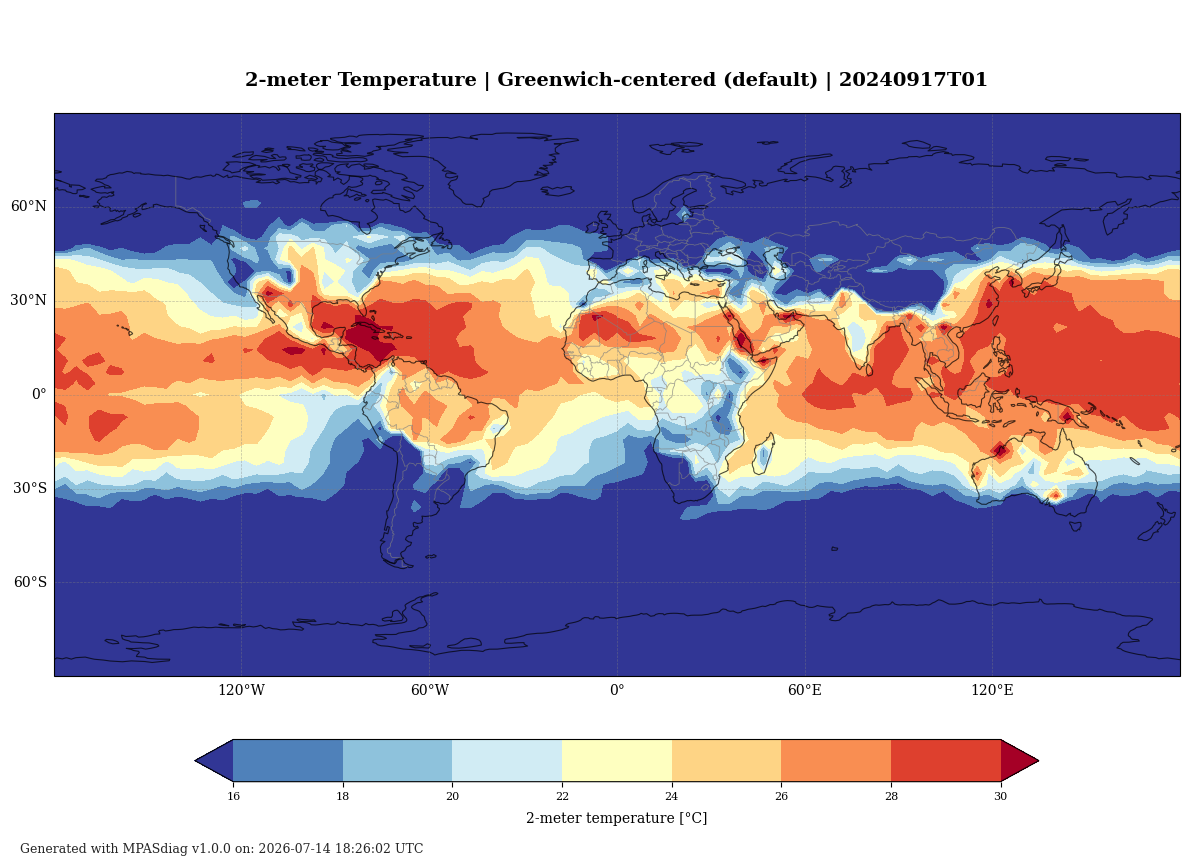

In [6]:
# 1. Default PlateCarree (central_longitude defaults to 0 -- unchanged output)
plotter = md.MPASSurfacePlotter(figsize=(12, 10), dpi=100)
fig, ax = plotter.create_surface_map(
    lon=lon, lat=lat, data=surface_var.values, var_name='t2m', bounds=bounds,
    style=md.SurfaceMapStyle(
        plot_type='contourf',
        title=f'2-meter Temperature | Greenwich-centered (default) | {valtime_str}',
    ),
    data_array=surface_var, config=cfg)
plotter.save_plot(f'./output/2m_temperature_default_{valtime_str}', formats=['png'])


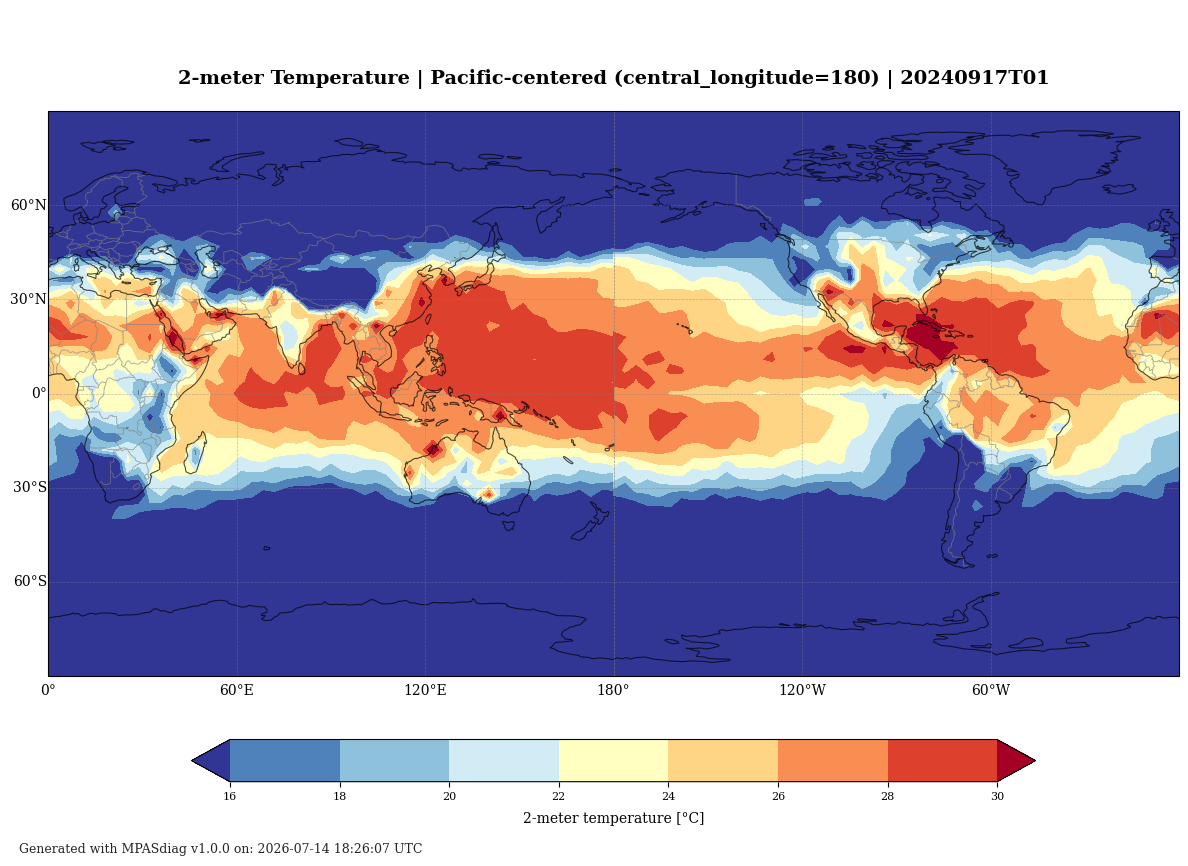

In [7]:
# 2. Pacific-centered PlateCarree (central_longitude=180)
plotter = md.MPASSurfacePlotter(figsize=(12, 10), dpi=100)
fig, ax = plotter.create_surface_map(
    lon=lon, lat=lat, data=surface_var.values, var_name='t2m', bounds=bounds,
    style=md.SurfaceMapStyle(
        plot_type='contourf',
        central_longitude=180.0,
        title=f'2-meter Temperature | Pacific-centered (central_longitude=180) | {valtime_str}',
    ),
    data_array=surface_var, config=cfg)
plotter.save_plot(f'./output/2m_temperature_pacific_{valtime_str}', formats=['png'])


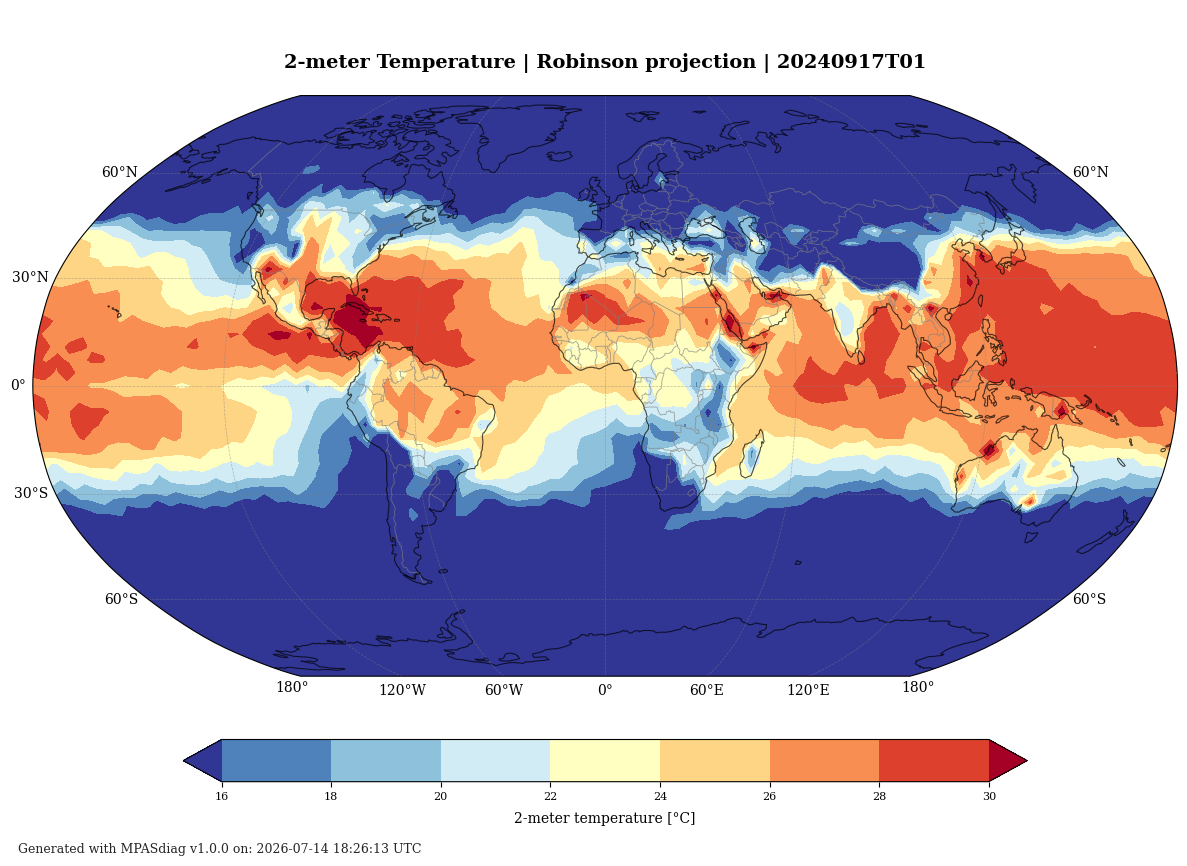

In [8]:
# 3. Robinson projection with center set via proj_kwargs (full passthrough)
plotter = md.MPASSurfacePlotter(figsize=(12, 10), dpi=100)
fig, ax = plotter.create_surface_map(
    lon=lon, lat=lat, data=surface_var.values, var_name='t2m', bounds=bounds,
    style=md.SurfaceMapStyle(
        plot_type='contourf',
        projection='Robinson',
        proj_kwargs={'central_longitude': 0.0},
        title=f'2-meter Temperature | Robinson projection | {valtime_str}',
    ),
    data_array=surface_var, config=cfg)
plotter.save_plot(f'./output/2m_temperature_robinson_{valtime_str}', formats=['png'])
